# EDA — Medical Abstracts TC Corpus

Exploração antes de qualquer decisão de modelagem. Lógica reutilizável vive em `src/`; este notebook só a importa e explora.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.neighbors import NearestNeighbors

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load import download_raw, load_raw  # noqa: E402

RAW_DIR = PROJECT_ROOT / "data" / "raw"
download_raw(RAW_DIR)
df = load_raw(RAW_DIR)
df.shape

(14438, 3)

## 1. Volume e distribuição de classes

Train e test do corpus original são concatenados aqui — o split original tem vazamento
grave (ver `docs/data_card.md`) e não é usado como referência. Um split próprio é feito
nas caixas 1.5/1.6, depois do dedupe.

In [2]:
counts = df["original_label"].value_counts()
pct = (counts / len(df) * 100).round(1)
summary = pd.DataFrame({"n": counts, "%": pct})
print(f"Total: {len(df)} amostras")
summary

Total: 14438 amostras


,n,%
original_label,,
general pathological conditions,4805,33.3
neoplasms,3163,21.9
cardiovascular diseases,3051,21.1
nervous system diseases,1925,13.3
digestive system diseases,1494,10.3


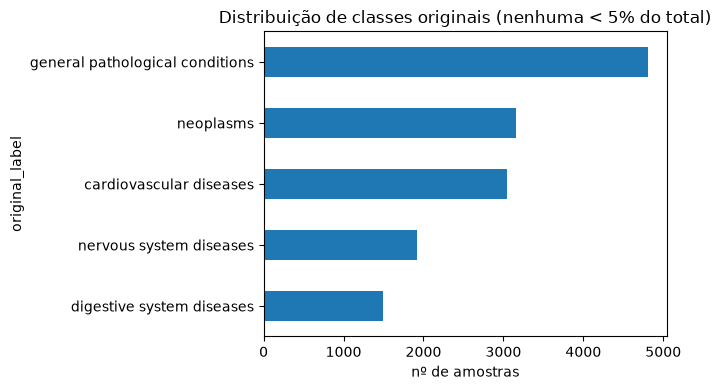

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
counts.sort_values().plot.barh(ax=ax)
ax.set_xlabel("nº de amostras")
ax.set_title("Distribuição de classes originais (nenhuma < 5% do total)")
fig.tight_layout()

## 2. Comprimento dos abstracts (tokens e caracteres)

In [4]:
df["n_chars"] = df["text"].str.len()
df["n_tokens"] = df["text"].str.split().str.len()
df[["n_chars", "n_tokens"]].describe(percentiles=[0.5, 0.95])

,n_chars,n_tokens
count,14438.000000,14438.000000
mean,1230.665120,179.937110
std,507.347695,76.549766
min,170.000000,24.000000
50%,1210.000000,176.000000
95%,2050.000000,302.000000
max,3999.000000,596.000000


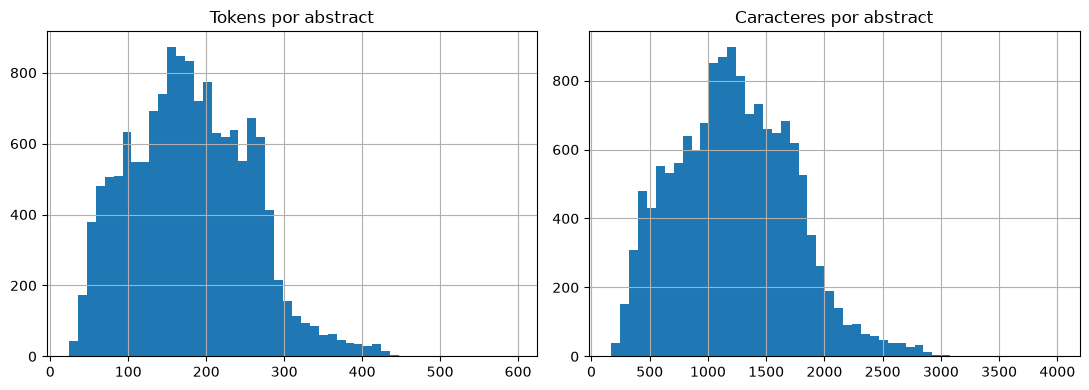

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["n_tokens"].hist(bins=50, ax=axes[0])
axes[0].set_title("Tokens por abstract")
df["n_chars"].hist(bins=50, ax=axes[1])
axes[1].set_title("Caracteres por abstract")
fig.tight_layout()

## 3. Duplicatas exatas

Texto normalizado (strip + lowercase) para não deixar diferença de espaçamento/caixa
esconder duplicatas reais.

In [6]:
norm_text = df["text"].str.strip().str.lower()
n_exact_dup = norm_text.duplicated().sum()
n_unique = norm_text.nunique()
print(f"Linhas totais: {len(df)}")
print(f"Textos únicos: {n_unique}")
print(
    f"Duplicatas exatas (excedente sobre a 1ª ocorrência): {n_exact_dup} ({100 * n_exact_dup / len(df):.1f}%)"
)

Linhas totais: 14438
Textos únicos: 11227
Duplicatas exatas (excedente sobre a 1ª ocorrência): 3211 (22.2%)


## 4. Near-duplicates (similaridade de cosseno sobre TF-IDF)

Vizinho mais próximo de cada documento (excluindo ele mesmo) via `NearestNeighbors`
com métrica de cosseno — eficiente o bastante para rodar em segundos neste corpus,
sem precisar materializar a matriz de similaridade completa (14438² seria ~1.7 GB
em memória).

In [7]:
tfidf = TfidfVectorizer(max_features=20000)
X_tfidf = tfidf.fit_transform(df["text"])

nn = NearestNeighbors(n_neighbors=2, metric="cosine", algorithm="brute", n_jobs=-1)
nn.fit(X_tfidf)
dist, _ = nn.kneighbors(X_tfidf)
nearest_sim = 1 - dist[:, 1]  # coluna 0 é o próprio documento (distância 0)

for thresh in (0.99, 0.95, 0.90, 0.80):
    n = (nearest_sim >= thresh).sum()
    print(f"documentos com um vizinho de similaridade >= {thresh}: {n} ({100 * n / len(df):.1f}%)")

documentos com um vizinho de similaridade >= 0.99: 6141 (42.5%)
documentos com um vizinho de similaridade >= 0.95: 6143 (42.5%)
documentos com um vizinho de similaridade >= 0.9: 6143 (42.5%)
documentos com um vizinho de similaridade >= 0.8: 6145 (42.6%)


**Observação:** a contagem quase não cresce entre os limiares 0.99 e 0.80 — a maior
parte dos "vizinhos muito próximos" já são as duplicatas exatas da seção 3, não
paráfrases quase-idênticas. Reforça que o dedupe exato (caixa 1.5) resolve a maior
parte do problema; near-dup por similaridade pega só a franja adicional.

## 5. Vocabulário

In [8]:
cv = CountVectorizer(token_pattern=r"(?u)\b\w+\b")
X_counts = cv.fit_transform(df["text"])
vocab_size = len(cv.vocabulary_)
term_counts = np.asarray(X_counts.sum(axis=0)).ravel()
hapax = int((term_counts == 1).sum())

print(f"Tamanho do vocabulário: {vocab_size}")
print(f"Hapax legomena (termos que aparecem 1 vez): {hapax} ({100 * hapax / vocab_size:.1f}%)")

Tamanho do vocabulário: 38096
Hapax legomena (termos que aparecem 1 vez): 8956 (23.5%)


### OOV entre os splits originais

Quantos termos do vocabulário de teste nunca aparecem no vocabulário de treino, no
split **original** do corpus (só para caracterizar o dataset — o split usado no
projeto é outro, feito nas caixas 1.5/1.6).

In [9]:
N_TRAIN_ORIGINAL = 11550  # linhas de medical_tc_train.csv, antes da concatenação

vocab_train = set(
    CountVectorizer(token_pattern=r"(?u)\b\w+\b")
    .fit(df["text"].iloc[:N_TRAIN_ORIGINAL])
    .vocabulary_
)
vocab_test = set(
    CountVectorizer(token_pattern=r"(?u)\b\w+\b")
    .fit(df["text"].iloc[N_TRAIN_ORIGINAL:])
    .vocabulary_
)
oov = vocab_test - vocab_train

print(f"Vocabulário do test original: {len(vocab_test)}")
print(
    f"Termos do test ausentes do vocabulário de train: {len(oov)} ({100 * len(oov) / len(vocab_test):.1f}%)"
)

Vocabulário do test original: 20298
Termos do test ausentes do vocabulário de train: 2841 (14.0%)


## 6. Termos discriminativos por classe (χ²)

Top termos por classe via `chi2` one-vs-rest sobre o TF-IDF — evidência barata de
interpretabilidade, útil no vídeo.

In [10]:
feature_names = np.array(tfidf.get_feature_names_out())
top_terms = {}
for cls in df["original_label"].unique():
    y_bin = (df["original_label"] == cls).astype(int)
    scores, _ = chi2(X_tfidf, y_bin)
    top_terms[cls] = list(feature_names[np.argsort(scores)[-10:][::-1]])

pd.DataFrame.from_dict(top_terms, orient="index").T

,general pathological conditions,neoplasms,digestive system diseases,nervous system diseases,cardiovascular diseases
0,cancer,cancer,hepatitis,brain,coronary
1,carcinoma,tumor,cirrhosis,seizures,myocardial
2,tumor,carcinoma,colitis,cerebral,ventricular
3,tumors,tumors,ulcer,sleep,hypertension
4,hypertension,cell,bowel,migraine,heart
5,cholesterol,breast,gallbladder,headache,pressure
6,deletion,metastases,diarrhea,stroke,artery
7,respiratory,cells,biliary,meningitis,aortic
8,breast,chemotherapy,esophageal,motor,left
9,infections,malignant,crohn,epilepsy,cardiac


## 7. Sobreposição lexical entre classes

Jaccard entre os vocabulários de cada par de classes (`min_df=2` para não deixar
erros de digitação isolados inflarem a interseção).

In [11]:
import itertools

classes = df["original_label"].unique()
class_vocabs = {
    c: set(
        CountVectorizer(token_pattern=r"(?u)\b\w+\b", min_df=2)
        .fit(df.loc[df["original_label"] == c, "text"])
        .vocabulary_
    )
    for c in classes
}

rows = []
for a, b in itertools.combinations(classes, 2):
    inter = len(class_vocabs[a] & class_vocabs[b])
    union = len(class_vocabs[a] | class_vocabs[b])
    rows.append({"classe_a": a, "classe_b": b, "jaccard": round(inter / union, 3)})

pd.DataFrame(rows).sort_values("jaccard", ascending=False)

,classe_a,classe_b,jaccard
3,general pathological conditions,cardiovascular diseases,0.528
0,general pathological conditions,neoplasms,0.522
9,nervous system diseases,cardiovascular diseases,0.502
2,general pathological conditions,nervous system diseases,0.489
7,digestive system diseases,nervous system diseases,0.467
4,neoplasms,digestive system diseases,0.467
6,neoplasms,cardiovascular diseases,0.466
8,digestive system diseases,cardiovascular diseases,0.462
5,neoplasms,nervous system diseases,0.459
1,general pathological conditions,digestive system diseases,0.438


## 8. Síntese e implicações para o pipeline

- **Volume:** 14.438 amostras, 5 classes, todas acima de 10% do total — sem
  desbalanceamento que force ajuste no mapeamento de urgência (ADR-0001).
- **Duplicatas:** ~22% do corpus são duplicatas exatas. Confirma que dedupe **antes**
  do split (HR-1.3) não é opcional — é a causa raiz do vazamento achado em NV-6.
- **Near-duplicates:** quase inteiramente cobertas pelas duplicatas exatas — dedupe
  exato resolve a maior parte; near-dup por similaridade cobre só a franja restante.
- **Vocabulário:** 38k termos, 23,5% hapax — típico de texto técnico/científico com
  muitos termos raros (nomes de fármacos, achados específicos).
- **Termos discriminativos:** claramente interpretáveis e clinicamente coerentes por
  classe (ex. `coronary`/`myocardial` em cardiovascular, `seizures`/`stroke` em
  sistema nervoso) — bom sinal para um classificador linear em F2.
- **Sobreposição lexical:** moderada (~0.44–0.53) entre todos os pares de classe,
  esperada em texto médico que compartilha vocabulário clínico/anatômico comum;
  "condições patológicas gerais" tem a maior sobreposição com as demais, consistente
  com ser a classe "catch-all" mais heterogênea.
- **Ação concreta:** dedupe (exato + near-dup) antes de qualquer split, depois split
  estratificado próprio com seed fixa (caixas 1.5/1.6).